In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import graph_style as gs
import fig_helper as fh

gs.set_graph_style(1.0)


In [53]:

date = "2026-08-11"
rid = 136433

dict = fh.load_data(rid, date)
print(dict["datasets"].keys())

freq = np.array(dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"])
pop = np.array(
    dict["datasets"][f"ndscan.rid_{rid}.points.channel_count_rate"]
)/1000
argsort = np.argsort(freq)
freq = freq[argsort] / 1e6 # MHz
pop = pop[argsort]

freq_max = 2.8725
freq_min = 2.8685
freq_mask = (freq > freq_min) & (freq < freq_max)
freq = freq[freq_mask]
pop = pop[freq_mask]


dict_keys(['ndscan.rid_136433.analysis_result.baseline', 'ndscan.rid_136433.analysis_result.centre_freq', 'ndscan.rid_136433.analysis_result.centre_freq_err', 'ndscan.rid_136433.analysis_result.contrast', 'ndscan.rid_136433.analysis_result.fit_counts', 'ndscan.rid_136433.analysis_result.fit_freqs', 'ndscan.rid_136433.analysis_result.found_peak', 'ndscan.rid_136433.analysis_result.lorentzian_height', 'ndscan.rid_136433.analysis_result.lorentzian_width', 'ndscan.rid_136433.analysis_results', 'ndscan.rid_136433.annotations', 'ndscan.rid_136433.axes', 'ndscan.rid_136433.channels', 'ndscan.rid_136433.completed', 'ndscan.rid_136433.fragment_fqn', 'ndscan.rid_136433.ndscan_schema_revision', 'ndscan.rid_136433.online_analyses', 'ndscan.rid_136433.points.axis_0', 'ndscan.rid_136433.points.channel_count_rate', 'ndscan.rid_136433.seed', 'ndscan.rid_136433.source_id', 'trap.tight.mode_freqs.radial_hf', 'trap.tight.tickle.radial_hf.freq_fwhm', 'trap.tight.tickle.radial_hf.freq_mode'])


Actual repeats: 1000
Central frequency: 2.870341 ± 0.000023 MHz
FWHM: 280.491 ± 48.508 kHz


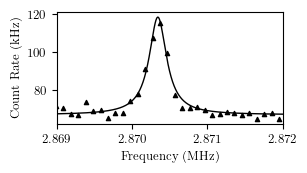

In [58]:
def lorentzian(x, A, B, x0, gamma):
    return A * (gamma**2 / ((x - x0) ** 2 + gamma**2)) + B

p_fit, p_cov = curve_fit(
    lorentzian,
    freq,
    pop,
    p0=[np.max(pop), np.min(pop), freq[np.argmax(pop)], 3e-4],
    bounds=([0, 0, freq_min, 0], [np.inf, np.inf, freq_max, 1])
)

p_err = np.sqrt(np.diag(p_cov))

""" bootstrap to get error bars """
num_repeats = 1000
actual_repeats = 0
p_err_cum = 0
for i in range(num_repeats):
    rand_args = np.random.choice(len(pop), size=len(pop), replace=True)
    pop_bootstrap = pop[rand_args]
    freq_bootstrap = freq[rand_args]
    # plt.plot(freq_bootstrap, pop_bootstrap, "o", alpha=0.5)
    try:
        p_fit_bootstrap, _ = curve_fit(
            lorentzian,
            freq_bootstrap,
            pop_bootstrap,
            p0=[np.max(pop), np.min(pop), freq[np.argmax(pop)], 3e-4],
            bounds=([0, 0, freq_min, 1e-4], [np.inf, np.inf, freq_max, 6e-4])
        )
        actual_repeats += 1
    except RuntimeError:
        continue
    p_err_cum += (p_fit_bootstrap - p_fit) ** 2
print(f"Actual repeats: {actual_repeats}")
p_err_bs = np.sqrt(p_err_cum / actual_repeats)

print(f"Central frequency: {p_fit[2]:.6f} ± {p_err_bs[2]:.6f} MHz")
print(f"FWHM: {1e6*2*p_fit[3]:.3f} ± {1e6*2*p_err_bs[3]:.3f} kHz")

x_fit = np.linspace(
    np.min(freq),
    np.max(freq),
    1000,
)
y_fit = lorentzian(x_fit, *p_fit)


fig = plt.figure()

fig_width = gs.get_fig_width()/2
fig_height = fig_width /2
fig.set_size_inches(fig_width, fig_height)
c = "k"
plt.plot(
    x_fit,
    y_fit,
    color=c,
    ls="-"
)
plt.scatter(
    freq , pop, color=c,
)
plt.xticks(np.arange(2.869, 2.873, 0.001))
plt.xlim(2.869, 2.872)
plt.grid(None)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Count Rate (kHz)")
f_name = "..\\..\\pdf_figure\\ch4\\tickle.pdf"
plt.savefig(f_name, bbox_inches="tight")

In [ ]:
dict_keys(['ndscan.rid_136433.analysis_result.baseline',
'ndscan.rid_136433.analysis_result.centre_freq',
'ndscan.rid_136433.analysis_result.centre_freq_err',
'ndscan.rid_136433.analysis_result.contrast',
'ndscan.rid_136433.analysis_result.fit_counts',
'ndscan.rid_136433.analysis_result.fit_freqs',
'ndscan.rid_136433.analysis_result.found_peak',
'ndscan.rid_136433.analysis_result.lorentzian_height',
'ndscan.rid_136433.analysis_result.lorentzian_width',
'ndscan.rid_136433.analysis_results', 'ndscan.rid_136433.annotations',
'ndscan.rid_136433.axes', 'ndscan.rid_136433.channels',
'ndscan.rid_136433.completed', 'ndscan.rid_136433.fragment_fqn',
'ndscan.rid_136433.ndscan_schema_revision', 'ndscan.rid_136433.online_analyses',
'ndscan.rid_136433.points.axis_0',
'ndscan.rid_136433.points.channel_count_rate', 'ndscan.rid_136433.seed',
'ndscan.rid_136433.source_id', 'trap.tight.mode_freqs.radial_hf',
'trap.tight.tickle.radial_hf.freq_fwhm',
'trap.tight.tickle.radial_hf.freq_mode'])
